# Prueba real con audio creado por los integrantes

1. El audio se toma a partir de la carpeta 'data/raw/voz.wav'.
2. Se le inyecta un pitido de 800Hz
3. Como creamos un "nuevo" audio, se guarda para lograr un antes y un despues.
4. Se limpia mediante la transformada de Fourier. De igual forma, al tener la señal limpia, se guarda.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import soundfile as sf
from scipy.fft import fft, ifft

# 1. Importamos tus módulos
sys.path.append("..")
from src.audio_loader import load_audio
from src.filters import apply_notch_mask

# 2. Cargar tu voz real
RUTA_VOZ = Path("../data/raw/voz.wav")
senal_ideal, sample_rate = load_audio(RUTA_VOZ)

# 3. SInyectar ruido
t = np.arange(len(senal_ideal)) / sample_rate
pitido_molesto = 0.5 * np.sin(2 * np.pi * 800 * t)
senal_arruinada = senal_ideal + pitido_molesto

# Guardamos el audio arruinado para la presentación
sf.write("../data/processed/voz_arruinada.wav", senal_arruinada, sample_rate)

# 4. RESCATE: Limpiamos con la Transformada de Fourier
espectro_arruinado = fft(senal_arruinada)
# Aplicamos la máscara específicamente en 800 Hz
espectro_limpio = apply_notch_mask(espectro_arruinado, center_hz=800.0, bandwidth_hz=10.0, sample_rate=sample_rate)
# Reconstrucción
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
sf.write("../data/processed/voz_rescatada.wav", senal_rescatada, sample_rate)

print("¡Audio arruinado y rescatado con éxito!")
print("Revisa la carpeta 'data/processed/' para escuchar el resultado.")

¡Audio arruinado y rescatado con éxito!
Revisa la carpeta 'data/processed/' para escuchar el resultado.


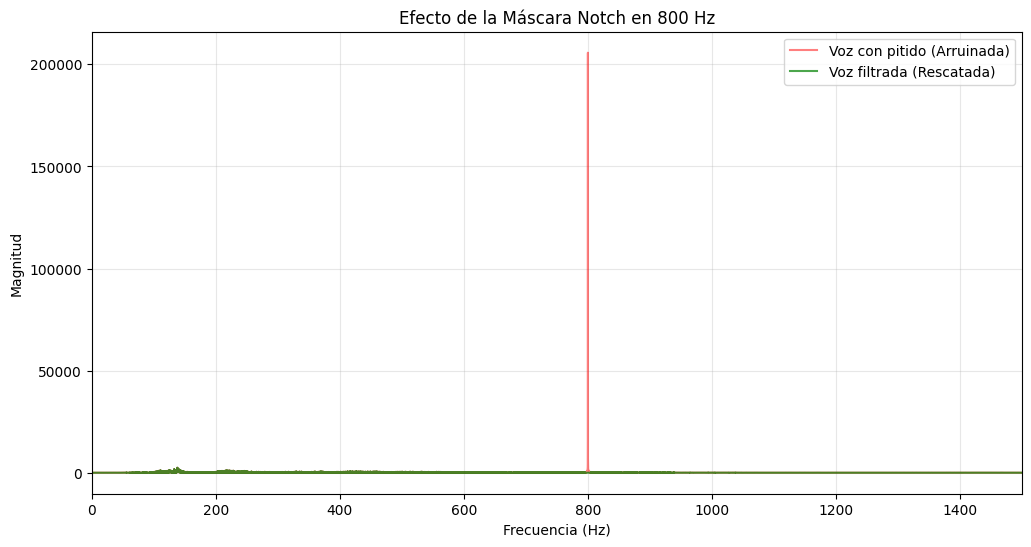

In [ ]:
import matplotlib.pyplot as plt
from scipy.fft import fftfreq

# Preparamos los datos para graficar
N = len(senal_arruinada)
frecuencias = fftfreq(N, 1 / sample_rate)
mitad = N // 2

# Magnitudes
mag_arruinada = np.abs(fft(senal_arruinada)[:mitad])
mag_rescatada = np.abs(fft(senal_rescatada)[:mitad])

plt.figure(figsize=(12, 6))
plt.plot(frecuencias[:mitad], mag_arruinada, color='red', alpha=0.5, label='Voz con pitido (Arruinada)')
plt.plot(frecuencias[:mitad], mag_rescatada, color='green', alpha=0.7, label='Voz filtrada (Rescatada)')

plt.title("Efecto de la Máscara Notch en 800 Hz")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Magnitud")
plt.xlim(0, 1500)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Inicio prueba arcaica

# ➡️ Si queremos hacer la transformada de Fourier, paso a paso.

No se puede hacer una forma mano a mano debido a la complejidad computacional y el tiempo. Porque, por ejemplo, los ejemplos que hemos estado trabajando, que solo tiene una duracion de apenas unos segundos, tiene una tasa de muestreo estandar de 44100 Hz, por lo que hay, unas 130000 muestras. De hecho, se tiene que realizar una cantidad de multiplicaciones equivalente a N^2 (es decir, 130,000 * 130,000). Una cantidad absurda de iteraciones, que probablemente se tarde horas.

✅ Pero para lograr demostrar al menos, de una manera muy primitiva y arcaica, una transformada de Fourier, paso a paso, vamos a crear un audio ridículamente corto y con una frecuencia de muestreo minúscula. En lugar de procesar un segundo de audio real (44,100 números), procesamos un fragmento microscópico de solamente 8 números (es decir, N=8). A esa escala, la computadora tiene que hacer apenas 64 multiplicaciones (8 * 8). El algoritmo recorrerá el "mini-audio", probará la frecuencia 0, luego la frecuencia 1, luego la 2... hasta la 7, desarmando la señal paso a paso.

Para que puedas obtener un archivo de audio .wav real usando este código arcaico sin que tu computadora tarde 3 días en calcularlo, el secreto es procesar un micro-audio. Crearemos un audio de solo medio segundo, con una frecuencia de muestreo muy baja (2000 Hz en lugar de 44100 Hz).Esto nos dará exactamente 1000 muestras. Tu computadora tendrá que hacer 1,000,000 de cálculos (1000 * 1000$), lo cual le tomará solo un par de segundos, ¡y lograrás tu demostración de principio a fin!

In [2]:
import cmath
import math
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt

# --- 1. LAS MATEMÁTICAS ARCAICAS (A MANO) ---

def dft_primitiva(x):
    """Transformada Discreta de Fourier paso a paso (Viaje a la frecuencia)"""
    N = len(x)
    X = []
    for k in range(N):
        suma = 0j
        for n in range(N):
            angulo = -2j * cmath.pi * k * n / N
            suma += x[n] * cmath.exp(angulo)
        X.append(suma)
    return X

def idft_primitiva(X):
    """Transformada INVERSA Discreta de Fourier paso a paso (Viaje al tiempo)"""
    N = len(X)
    x_reconstruido = []
    for n in range(N):
        suma = 0j
        for k in range(N):
            angulo = 2j * cmath.pi * k * n / N  # ¡Ángulo positivo!
            suma += X[k] * cmath.exp(angulo)
        # Dividimos entre N y tomamos la parte real (el audio físico no tiene números imaginarios)
        x_reconstruido.append((suma / N).real)
    return x_reconstruido

# --- 2. EL EXPERIMENTO CON MICRO-AUDIO ---

# Configuramos un audio minúsculo (0.5 segundos a 2000 Hz = Solo 1000 números)
sample_rate = 2000
duration = 0.5
N = int(sample_rate * duration)
t = np.arange(N) / sample_rate

print(f"Iniciando procesamiento de {N} muestras...")
print("Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...")

# Creamos una nota pura (440 Hz) y le inyectamos un zumbido súper grave (100 Hz)
senal_pura = 0.5 * np.sin(2 * np.pi * 440 * t)
ruido_grave = 0.5 * np.sin(2 * np.pi * 100 * t)
micro_audio_ruidoso = senal_pura + ruido_grave

# Guardamos el audio con ruido para la comparación
sf.write("../data/processed/arcaico_ruidoso.wav", micro_audio_ruidoso, sample_rate)

# --- 3. APLICANDO EL CICLO ---

# PASO A: Convertimos a frecuencias (Tardará un poquito)
espectro = dft_primitiva(micro_audio_ruidoso)

# PASO B: Aplicamos una Máscara Primitiva para borrar los 100 Hz
# (A 2000 Hz de sample rate, los 100 Hz caen exactamente en el índice k=25 y k=975)
espectro[25] = 0j
espectro[975] = 0j

# PASO C: Reconstruimos el audio usando nuestra Inversa Arcaica
micro_audio_limpio = idft_primitiva(espectro)

# Guardamos el resultado limpio
sf.write("../data/processed/arcaico_limpio.wav", micro_audio_limpio, sample_rate)

print("¡Proceso completado con éxito!")
print("Revisa los archivos 'arcaico_ruidoso.wav' y 'arcaico_limpio.wav'")

Iniciando procesamiento de 1000 muestras...
Esto tomará unos 2 a 5 segundos (¡Imagina si fueran 100,000 muestras!)...
¡Proceso completado con éxito!
Revisa los archivos 'arcaico_ruidoso.wav' y 'arcaico_limpio.wav'


In [3]:
import time
import numpy as np
from scipy.fft import fft

# 1. Traemos nuestra función arcaica (si no la tienes en esta celda, cópiala de nuevo aquí)
def dft_primitiva_bench(x):
    N = len(x)
    X = []
    for k in range(N):
        suma = 0j
        for n in range(N):
            # Usamos math/cmath nativos o numpy, aquí con numpy puro para ser justos:
            angulo = -2j * np.pi * k * n / N
            suma += x[n] * np.exp(angulo)
        X.append(suma)
    return X

# 2. Creamos un audio de prueba de tamaño medio (ej. 2000 muestras)
# No lo hacemos más grande porque la DFT primitiva tardaría minutos.
N_muestras = 2000
sample_rate = 44100
t = np.arange(N_muestras) / sample_rate
audio_prueba = np.sin(2 * np.pi * 440 * t) + np.random.normal(0, 0.1, N_muestras)

print(f"--- INICIANDO BENCHMARK DE RENDIMIENTO ({N_muestras} muestras) ---")

# --- PRUEBA 1: Transformada Primitiva O(N^2) ---
inicio_arcaico = time.time()
resultado_arcaico = dft_primitiva_bench(audio_prueba)
fin_arcaico = time.time()
tiempo_arcaico = fin_arcaico - inicio_arcaico

# --- PRUEBA 2: Fast Fourier Transform O(N log N) ---
inicio_fft = time.time()
resultado_fft = fft(audio_prueba)
fin_fft = time.time()
tiempo_fft = fin_fft - inicio_fft

# --- RESULTADOS ---
print(f"Tiempo DFT Matemática a mano: {tiempo_arcaico:.4f} segundos")
print(f"Tiempo algoritmo FFT (SciPy): {tiempo_fft:.6f} segundos")

# Calculamos cuántas veces más rápido es el algoritmo FFT
if tiempo_fft > 0:
    aceleracion = tiempo_arcaico / tiempo_fft
    print(f"\n¡La FFT es {aceleracion:,.0f} veces más rápida!")
    print("Nota: Si hiciéramos esto con una canción de 3 minutos, la DFT tardaría")
    print("años en procesarse, mientras que la FFT lo haría en milisegundos.")

--- INICIANDO BENCHMARK DE RENDIMIENTO (2000 muestras) ---
Tiempo DFT Matemática a mano: 2.5691 segundos
Tiempo algoritmo FFT (SciPy): 0.001532 segundos

¡La FFT es 1,677 veces más rápida!
Nota: Si hiciéramos esto con una canción de 3 minutos, la DFT tardaría
años en procesarse, mientras que la FFT lo haría en milisegundos.


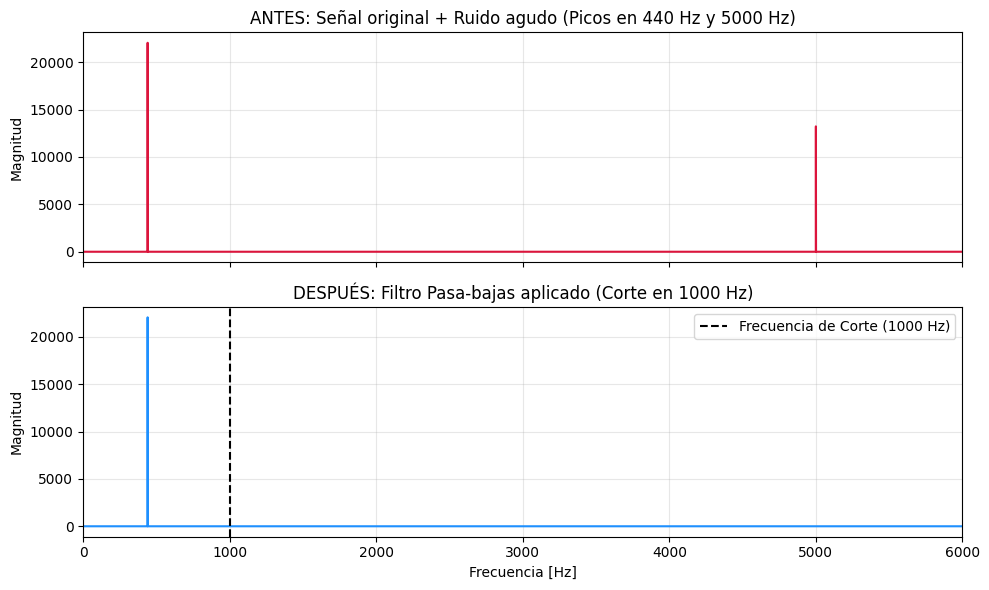

¡Prueba del filtro pasa-bajas completada!
Escucha los audios 'prueba_pasa_bajas_ruido.wav' y 'prueba_pasa_bajas_limpio.wav'


In [4]:
import sys
import numpy as np
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft, fftfreq
from pathlib import Path

# 1. Importamos tu nuevo filtro
sys.path.append("..")
from src.filters import apply_lowpass_mask

# 2. CREAMOS EL ESCENARIO DE PRUEBA
sample_rate = 44100
duration = 2.0 # 2 segundos
t = np.arange(int(sample_rate * duration)) / sample_rate

# Nuestra señal útil (440 Hz - Frecuencia baja/media)
senal_util = 0.5 * np.sin(2 * np.pi * 440 * t)

# El ruido (5000 Hz - Frecuencia muy alta, como un siseo agudo)
ruido_agudo = 0.3 * np.sin(2 * np.pi * 5000 * t)

# Mezclamos ambas
senal_con_siseo = senal_util + ruido_agudo

# Guardamos el audio arruinado para escucharlo
ruta_siseo = Path("../data/processed/prueba_pasa_bajas_ruido.wav")
sf.write(ruta_siseo, senal_con_siseo, sample_rate)

# 3. APLICAMOS EL FILTRO PASA-BAJAS
N = len(senal_con_siseo)
frecuencias = fftfreq(N, 1 / sample_rate)

# Pasamos al dominio frecuencial
espectro_siseo = fft(senal_con_siseo)

# LA MAGIA: Aplicamos el filtro. "Corta todo lo que esté por encima de 1000 Hz"
espectro_limpio = apply_lowpass_mask(espectro_siseo, cutoff_hz=1000.0, sample_rate=sample_rate)

# Regresamos al tiempo
senal_rescatada = np.real(ifft(espectro_limpio))

# Guardamos el audio rescatado
ruta_rescatada = Path("../data/processed/prueba_pasa_bajas_limpio.wav")
sf.write(ruta_rescatada, senal_rescatada, sample_rate)

# 4. VISUALIZACIÓN DE LA PRUEBA
mitad = N // 2
freqs_plot = frecuencias[:mitad]
mag_siseo = np.abs(espectro_siseo[:mitad])
mag_limpia = np.abs(espectro_limpio[:mitad])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.plot(freqs_plot, mag_siseo, color='crimson')
ax1.set_title("ANTES: Señal original + Ruido agudo (Picos en 440 Hz y 5000 Hz)")
ax1.set_ylabel("Magnitud")
ax1.set_xlim(0, 6000) # Vemos hasta 6000 Hz para notar el ruido
ax1.grid(alpha=0.3)

ax2.plot(freqs_plot, mag_limpia, color='dodgerblue')
ax2.set_title("DESPUÉS: Filtro Pasa-bajas aplicado (Corte en 1000 Hz)")
ax2.set_xlabel("Frecuencia [Hz]")
ax2.set_ylabel("Magnitud")
# Dibujamos una línea vertical punteada para mostrar dónde pasó "la podadora"
ax2.axvline(x=1000, color='black', linestyle='--', label='Frecuencia de Corte (1000 Hz)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("¡Prueba del filtro pasa-bajas completada!")
print("Escucha los audios 'prueba_pasa_bajas_ruido.wav' y 'prueba_pasa_bajas_limpio.wav'")

➡️ En la gráfica: La gráfica superior (roja) mostrará claramente dos rascacielos: uno en 440 Hz y otro muy lejos a la derecha, en 5000 Hz. En la gráfica inferior (azul), verás una línea negra punteada en 1000 Hz. A partir de esa línea hacia la derecha, ¡absolutamente todo es un desierto plano (cero)! El pico de 5000 Hz fue erradicado.

Para probar el Filtro Pasa-bajas, necesitamos una señal que tenga exactamente lo que este filtro ataca: ruido de alta frecuencia (como el "siseo" de una radio desintonizada o el pitido de un mosquito).

Vamos a crear una prueba rápida donde generamos tu nota musical de 440 Hz (baja frecuencia) y le sumamos un pitido agudísimo y molesto de 5000 Hz (alta frecuencia). Luego, le pasaremos "la podadora" de tu filtro pasa-bajas para cortar todo lo que esté por encima de 1000 Hz.

# Final prueba arcaica